# Getting started: the NiSpace object

This notebook introduces the core NiSpace API through a complete, step-by-step colocalization analysis. If you haven't already, have a look at the [Spatial Colocalization notebook](intro1_spatial_colocalizations.ipynb) for the conceptual background.

We'll use a NeuroQuery meta-analytic map for "pain" as our input and test whether it colocalizes with a set of PET-derived neurotransmitter receptor maps. This is a clean, self-contained example with a nice biological story.

In [1]:
# make progress bars render as text in the docs
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

## The input map: a NeuroQuery pain map

We need a brain map to start with. I downloaded a meta-analytic map from [NeuroQuery](https://neuroquery.org/query?text=pain) — a tool that generates brain activation maps from text queries against the neuroimaging literature. The map for "pain" is a z-score image reflecting how consistently the pain literature reports activation across brain regions.

Technically this is not a T-map from a single study, but it serves our purpose perfectly: it's a plausible spatial pattern of pain-related brain activity, and it lives in MNI space like all our reference data.

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

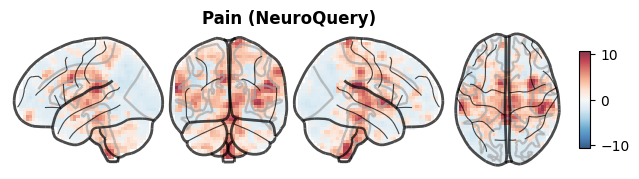

In [2]:
from nispace.io import load_img
from nispace.plotting import brainplot

# load the pain map
pain_map = load_img("neuroquery/pain.nii.gz")

# plot it
brainplot(pain_map, title="Pain (NeuroQuery)")

The map shows the expected pattern: activation in regions associated with pain processing, including the insula, anterior cingulate cortex, and somatosensory cortex.

## Reference data: PET receptor maps

For our reference maps, we'll use NiSpace's curated PET receptor dataset. This collection contains group-average receptor density maps for a wide range of neurotransmitter receptors and transporters, derived from PET studies in healthy subjects.

We fetch the data already parcellated into our target parcellation. This is much faster than loading the volumetric images and parcellating them on the fly — NiSpace ships pre-parcellated versions of all reference datasets.

In [3]:
from nispace.datasets import fetch_reference

# fetch the PET maps, pre-parcellated into Schaefer200
# collection="UniqueTracers" picks one representative tracer per receptor target
pet_maps = fetch_reference(
    "pet",
    parcellation="Schaefer200",
    collection="UniqueTracers",
    print_references=False  # suppress the long reference list for now
)

print(f"PET DataFrame: {pet_maps.shape[0]} maps x {pet_maps.shape[1]} parcels")
pet_maps.head(3)

INFO | 22/05/26 12:04:45 | nispace.datasets: Loading pet maps.
INFO | 22/05/26 12:04:45 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 22/05/26 12:04:45 | nispace.datasets: Filtering maps by collection.
INFO | 22/05/26 12:04:45 | nispace.datasets: Loading data parcellated with 'Schaefer200'
PET DataFrame: 29 maps x 200 parcels


hemi-L_div-Vis_lab-1  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.559112   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.497289   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.537978   

                                                            hemi-L_div-Vis_lab-2  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.594449   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.557331   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.540918   

                                                            hemi-L_div-Vis_lab-3  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.564076   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.534445   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.548307   

                                                            hemi-L_div-Vis_lab-4  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.666908   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.572699   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.534142   

                                                            hemi-L_div-Vis_lab-5  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.602571   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.641106   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.534993   

                                                            hemi-L_div-Vis_lab-6  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.518207   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.430567   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.447078   

                                                            hemi-L_div-Vis_lab-7  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.688230   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.687770   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.548369   

                                                            hemi-L_div-Vis_lab-8  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.615766   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.589226   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.608136   

                                                            hemi-L_div-Vis_lab-9  \
set     map                                                                        
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.505019   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...              0.577158   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.502087   

                                                            hemi-L_div-Vis_lab-10  \
set     map                                                                         
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...               0.620761   
        target-r

The DataFrame has a two-level index: the first level is the neurotransmitter system ("set"), the second is the full tracer identifier. These sets are used later for X-Set Enrichment Analysis ([XSEA notebook](intro10_xsea.ipynb)) — for now we just treat the whole thing as a collection of maps.

## Initializing the NiSpace object

NiSpace follows an object-oriented design. We first create a `NiSpace` instance, passing all the data and configuration options. Processing happens later when we call the analysis methods.

The two central arguments are:
- `x`: the reference maps (here: PET receptor maps)
- `y`: the input map(s) we want to analyze (here: the pain map)

We also specify the parcellation, which tells NiSpace how to parcellate `y` (since it's a volumetric NIfTI image) and how to align it with `x` (which is already a parcellated DataFrame).

In [4]:
from nispace.api import NiSpace

nsp = NiSpace(
    x=pet_maps,        # reference maps
    y=pain_map,        # input map — will be parcellated automatically
    y_labels="Pain",   # a name for our input map
    parcellation="Schaefer200",
    n_proc=4,          # use 4 parallel processes where possible
    seed=42            # for reproducibility
)

print(nsp)

## Fitting: parcellation and data ingestion

Calling `fit()` is where actual data processing begins. For the pain map (a NIfTI image), this means parcellating it into the 200 Schaefer regions. For the PET maps (already a DataFrame), it validates and stores the data.

In [5]:
nsp.fit()

# inspect the parcellated pain map
print("Parcellated pain map:")
nsp.get_y()

INFO | 22/05/26 12:04:45 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***
INFO | 22/05/26 12:04:45 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 12:04:45 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 12:04:45 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 22/05/26 12:04:45 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 22/05/26 12:04:46 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'MNI152NLin2009cAsym'.
INFO | 22/05/26 12:04:46 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):
INFO | 22/05/26 12:04:46 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
WARNING | 22/05/26 12:04:46 | nispace.io: Parcellated data contains nan values!
I

Parcellating (4 proc): 100%|██████████| 1/1 [00:00<00:00, 38.53it/s]


INFO | 22/05/26 12:04:50 | nispace.api: Got 'y' data for 1 x 200 parcels.
INFO | 22/05/26 12:04:50 | nispace.api: Z-standardizing 'X' data.
Parcellated pain map:
INFO | 22/05/26 12:04:50 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
Pain,-0.436623,-1.075635,-0.893094,-0.887707,-1.139506,-1.259002,-1.339256,-1.083586,-1.389717,-0.828569,...,-0.463824,-0.154211,0.643321,-0.584073,-0.205924,0.174392,0.172215,-0.319737,-0.818837,-0.344202


The parcellated data is stored internally. `get_y()` returns the input maps, `get_x()` returns the reference maps — both as DataFrames with maps in rows and parcels in columns.

## Colocalization

Now for the core step: computing correlations between the pain map and each PET receptor map. We use Spearman rank correlation, which is robust to outliers and doesn't assume normally distributed data.

In [6]:
nsp.colocalize("spearman")

# get the results
colocs = nsp.get_colocalizations()
print(f"Results: {colocs.shape[0]} input maps x {colocs.shape[1]} reference maps")

# show sorted by colocalization value
colocs.T.sort_values(by="Pain", ascending=False)

INFO | 22/05/26 12:04:50 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 22/05/26 12:04:50 | nispace.api: Running 'spearman' colocalization.
INFO | 22/05/26 12:04:50 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 1941.81it/s]


INFO | 22/05/26 12:04:53 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
Results: 1 input maps x 29 reference maps


Pain
set                         map                                                         
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...  0.396341
                            target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017      0.271602
Histamine                   target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallez...  0.200932
Opiods/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vija...  0.189344
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.149997
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...  0.118618
Opiods/Endocannabinoids     target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.074165
Serotonin                   target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.021724
GABA                        target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.013084
General                     target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.012305
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.010763
                            target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg... -0.000110
Opiods/Endocannabinoids     target-CB1_tracer-omar_n-77_dx-hc_pub-normandin... -0.010928
Dopamine                    target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller... -0.016592
Noradrenaline/Acetylcholine target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hil... -0.064114
Serotonin                   target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beli... -0.089016
Dopamine                    target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g... -0.118877
Noradrenaline/Acetylcholine target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naga... -0.133059
Immunity                    target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018    -0.142044
General                     target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016 -0.147302
                            target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we... -0.147597
Immunity                    target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020     -0.164953
Glutamate                   target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic... -0.187846
General                     target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril... -0.210073
Serotonin                   target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-rad... -0.210178
General                     target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith... -0.271793
GABA                        target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-du... -0.273643
Serotonin                   target-5HT1b_tracer-p943_n-23_dx-hc_pub-savli2012  -0.314457
                            target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-s... -0.326149

The result is a DataFrame with one row per input map (here: "Pain") and one column per reference map. The values are Spearman ρ.

We can see which receptors show the strongest positive and negative colocalizations. But these bare correlation values don't come with reliable p-values yet — we haven't accounted for spatial autocorrelation. That's where permutation testing comes in.

## Permutation testing

We call `permute()` with `"maps"` to generate spatially-constrained null versions of the PET maps and recompute correlations 10,000 times. This gives us an empirical null distribution for each receptor.

We pass `p_tails="upper"` because our hypothesis is directional: we expect *positive* colocalizations with receptors involved in pain processing (opioids, noradrenergic/cholinergic pathways).

Null model details are covered in the [Null Models notebook](intro5_null_models.ipynb). For now, just note that by default NiSpace uses spin-based surrogate maps if possible (Alexander-Bloch method), which preserve the spatial autocorrelation of the original data.

In [7]:
nsp.permute(
    "maps",
    n_perm=10000,
    p_tails="upper",  # one-tailed: test for positive colocalization, default is "two"
)

# multiple comparison correction across the 29 receptor maps
nsp.correct_p(mc_method="fdr_bh")

p_values = nsp.get_p_values()

# show p-values sorted ascending
p_values.T.sort_values(by="Pain")

INFO | 22/05/26 12:04:53 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 22/05/26 12:04:53 | nispace.api: Permutation of: X maps.
INFO | 22/05/26 12:04:53 | nispace.api: Using default null method 'alexander_bloch' (parcellation null space: 'fsLR').
INFO | 22/05/26 12:04:53 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 22/05/26 12:04:53 | nispace.api: Loading observed colocalizations (method = 'spearman').
INFO | 22/05/26 12:04:53 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
INFO | 22/05/26 12:04:53 | nispace.api: Generating permuted X maps.
INFO | 22/05/26 12:04:53 | nispace.core.permute: No null maps found.
INFO | 22/05/26 12:04:53 | nispace.core.permute: Generating null maps (n = 10000, null_method = 'alexander_bloch').
INFO | 22/05/26 12:04:53 | nispace.core.parcellation: Lazy-loading parcellation image fo

Spin null maps: 100%|██████████| 29/29 [00:01<00:00, 24.53it/s]

INFO | 22/05/26 12:04:54 | nispace.nulls: Null data generation finished.
INFO | 22/05/26 12:04:54 | nispace.core.permute: Z-standardizing null maps.


INFO | 22/05/26 12:04:55 | nispace.api: Pre-ranking X and Y (null) data.


Null colocalizations (spearman, 4 proc): 100%|██████████| 10000/10000 [00:00<00:00, 13842.23it/s]


INFO | 22/05/26 12:05:00 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).
INFO | 22/05/26 12:05:00 | nispace.api: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 22/05/26 12:05:00 | nispace.api: Correction method: 'fdr_bh', alpha: 0.05, dimension: 'array'.
INFO | 22/05/26 12:05:00 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


Pain
set                         map                                                       
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...  0.0089
                            target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017      0.0643
Histamine                   target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallez...  0.1365
Opiods/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vija...  0.1552
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...  0.2490
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.2633
Opiods/Endocannabinoids     target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.3586
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.4518
General                     target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.4730
Serotonin                   target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.4762
GABA                        target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.4928
Opiods/Endocannabinoids     target-CB1_tracer-omar_n-77_dx-hc_pub-normandin...  0.5114
Dopamine                    target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...  0.5172
                            target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.5718
Noradrenaline/Acetylcholine target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hil...  0.6370
Serotonin                   target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beli...  0.6549
Dopamine                    target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.7160
Noradrenaline/Acetylcholine target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naga...  0.7783
Immunity                    target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018     0.8018
General                     target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016  0.8161
                            target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...  0.8186
Immunity                    target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020      0.8208
General                     target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...  0.8409
Serotonin                   target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-rad...  0.8601
Glutamate                   target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic...  0.8614
General                     target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...  0.8838
Serotonin                   target-5HT1b_tracer-p943_n-23_dx-hc_pub-savli2012   0.8936
                            target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-s...  0.9316
GABA                        target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-du...  0.9460

After correcting for spatial autocorrelation (via permutation) and for multiple comparisons across the 29 receptor maps (FDR), the cholinergic transporter VAChT stands out with the lowest p-value — consistent with the pain neuroscience literature.

Notice that the effect sizes haven't changed: permutation testing and `correct_p()` only affect the p-values, not the correlations.

## Visualizing the results

NiSpace has an integrated `plot()` method that picks a reasonable visualization automatically. Pass `mc_method="fdr_bh"` to show significance markers based on the corrected p-values.

INFO | 22/05/26 12:05:00 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 22/05/26 12:05:00 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 
INFO | 22/05/26 12:05:01 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
INFO | 22/05/26 12:05:01 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 
INFO | 22/05/26 12:05:01 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | fdrbh     | False       | False       | 
INFO | 22/05/26 12:05:01 | nispace.api: Creating categorical plot for method spearman, coloca

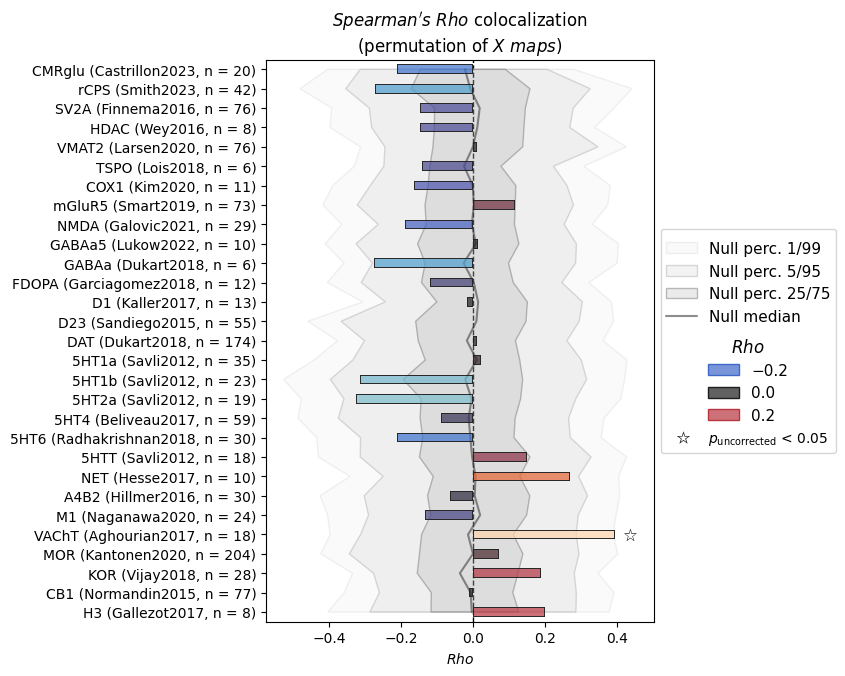

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x3134ab7c0>)

In [8]:
nsp.plot(mc_method="fdr_bh")

We can also visualize the input and reference maps as above, but here directly from NiSpace object:

INFO | 22/05/26 12:05:01 | nispace.api: *** NiSpace.plot_brain() ***
INFO | 22/05/26 12:05:01 | nispace.api: Plotting Y data (Y_transform='False').
INFO | 22/05/26 12:05:01 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 
WARNING | 22/05/26 12:05:01 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 22/05/26 12:05:01 | nispace.plotting: brainplot: threshold='auto' → 0.005351351574063301
INFO | 22/05/26 12:05:01 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


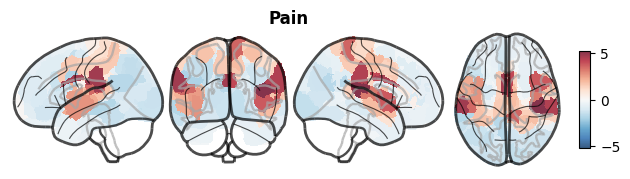

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [9]:
# the pain map
nsp.plot_brain(data="Y")

INFO | 22/05/26 12:05:05 | nispace.api: *** NiSpace.plot_brain() ***
INFO | 22/05/26 12:05:05 | nispace.api: Plotting X data (X_reduction='False').
INFO | 22/05/26 12:05:05 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 
WARNING | 22/05/26 12:05:05 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 22/05/26 12:05:05 | nispace.plotting: brainplot: threshold='auto' → 0.0004928179550915956
INFO | 22/05/26 12:05:05 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


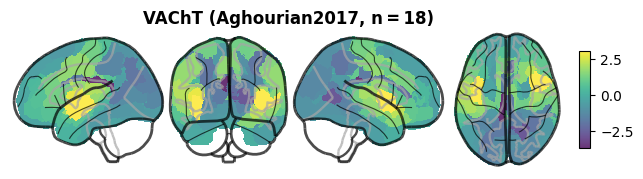

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [10]:
# the VAChT receptor map (strongest colocalization)
nsp.plot_brain(data="X", maps="VAChT", symmetric_cmap=False)

## Saving and loading

Analyses with 10,000 permutations take time. We can serialize the entire NiSpace object — including the null distributions — to disk with `to_pickle()`, and load it back with `from_pickle()`.

We recommend the `.pkl.blosc` format: Blosc compression keeps file sizes manageable without the speed penalty of gzip.

In [11]:
import os

# save, including the null distributions
nsp.to_pickle("nsp_pain.pkl.blosc")
print(f"With nulls:    {os.path.getsize('nsp_pain.pkl.blosc') / 1e6:.1f} MB")

# save without nulls — much smaller, but you lose the shading in plots
nsp.to_pickle("nsp_pain_no_nulls.pkl.blosc", save_nulls=False)
print(f"Without nulls: {os.path.getsize('nsp_pain_no_nulls.pkl.blosc') / 1e6:.1f} MB")

With nulls:    227.1 MB
Without nulls: 7.1 MB


In [12]:
# load it back
nsp_loaded = NiSpace.from_pickle("nsp_pain.pkl.blosc")

import numpy as np
assert np.allclose(
    nsp.get_colocalizations().values,
    nsp_loaded.get_colocalizations().values
)
print("Loaded successfully — results are identical.")

INFO | 22/05/26 12:05:09 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
INFO | 22/05/26 12:05:09 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
Loaded successfully — results are identical.


## Summary

The complete NiSpace workflow in six lines:

```python
nsp = NiSpace(x=reference_maps, y=input_map, parcellation="Schaefer200")
nsp.fit()                                          # parcellate + ingest
nsp.colocalize("spearman")                         # compute correlations
nsp.permute("maps", n_perm=10000, p_tails="upper") # permutation p-values
nsp.correct_p(mc_method="fdr_bh")                 # multiple comparisons correction
nsp.plot(mc_method="fdr_bh")                       # visualize
```

The next notebook covers [what datasets and parcellations are available, and how to bring in your own data](intro3_fetching_datasets.ipynb).